# Ablation study for the NSF model

load the data and train the model many times, testing all the possibilities and tuning hyperparameters.
- training recipe:
    * scaler
    * warmup
    * scheduler: cosine / plateau
    * gradient clipping
    * ema
    * loss: std / PAL
- model:
    * n. layers
    * layer dim.
- data:
    * casualties noise
    * undersampling for 0 dmg/casualites

repeat for 3 seeds, for all interesting disaster groups

#### imports

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time
import math

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils
from utils import TrainingHistory

### Set up

In [44]:
EVENT_GROUPS = ['Flood', 'Storm', 'Heat', 'Hail',] # 'Freeze', 'Wind', 'Heavy Rain', 'Drought', 'Wildfire'
SEEDS = [0]
EPOCHS = 20
BATCH_SIZE = 512
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [155]:
# load dataframes
dfs = utils.get_disaster_events_group_df(EVENT_GROUPS)
# get datasets
dss = utils.get_datasets_from_dataframes(dfs)
# split and normalize datasets
dss = utils.split_normalize_datasets(dss, device=device)

dfs_c = utils.get_disaster_events_group_df(['Wildfire'])
dss_c = utils.get_datasets_from_dataframes(dfs_c)
dss_c = utils.split_normalize_datasets(dss_c, device=device)


In [149]:
def repeated_training(training_fn, dss=dss):
    group_avg_val_losses = []
    group_avg_diff_damages = []
    group_avg_diff_casualties = []

    for group in EVENT_GROUPS:
        seed_avg_val_losses = []
        seed_avg_diff_damages = []
        seed_avg_diff_casualties = []
        
        print(f"Training for group {group}:")
        for seed in SEEDS:
            torch.manual_seed(seed)
            np.random.seed(seed)
            ds = dss[group]
            best_val_loss, add, adc, _ = training_fn(ds)
            seed_avg_val_losses.append(best_val_loss)
            seed_avg_diff_damages.append(add)
            seed_avg_diff_casualties.append(adc)
        print(f"Avg best val loss: {np.mean(seed_avg_val_losses):.3f} | Avg diff damages: {np.mean(seed_avg_diff_damages):.2f} | Avg diff casualties: {np.mean(seed_avg_diff_casualties):.2f}")
        group_avg_val_losses.append(np.mean(seed_avg_val_losses))
        group_avg_diff_damages.append(np.mean(seed_avg_diff_damages))
        group_avg_diff_casualties.append(np.mean(seed_avg_diff_casualties))

    res_str = f"Overall avg best val loss: {np.mean(group_avg_val_losses):.3f} | Overall avg diff damages: {np.mean(group_avg_diff_damages):.2f} | Overall avg diff casualties: {np.mean(group_avg_diff_casualties):.2f}"
    print("\n Average over all groups:")
    print(res_str)
    return res_str

In [127]:
def plot_learning_curve(history, title):
    plt.figure(figsize=(5, 3))
    plt.plot(history.train_losses, label='Train Loss')
    plt.plot(history.val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.plot()

## Training variations

### 1. Simple training

In [77]:
def simple_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None

    for epoch in range(epochs):
        t0 = time.time()

        # ================= TRAIN =================
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= max(len(train_loader), 1)

        # ================= VALIDATION =================
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)

        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()

    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [48]:
res = repeated_training(simple_training)

Training for group Flood:
Avg best val loss: -6.552 | Avg diff damages: 2483815.50 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -7.488 | Avg diff damages: 2486731.75 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -5.701 | Avg diff damages: 466.86 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -6.572 | Avg diff damages: 77666.28 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -6.578 | Overall avg diff damages: 1262170.12 | Overall avg diff casualties: 0.11


In [49]:
print(res)

Overall avg best val loss: -6.578 | Overall avg diff damages: 1262170.12 | Overall avg diff casualties: 0.11


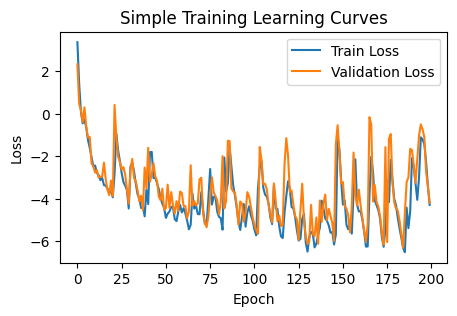

In [92]:
history = simple_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "Simple Training Learning Curves")

### 2. Mixed Precision

In [95]:
def mixed_prec_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)

    scaler = torch.amp.GradScaler("cuda")

    history = utils.TrainingHistory()
    best_val_loss = float("inf")

    for epoch in range(epochs):
        t0 = time.time()

        # ================= TRAIN =================
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = -flow(x).log_prob(y).mean()

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss /= max(len(train_loader), 1)

        # ================= VALIDATION =================
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)

        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    # Load best model
    flow.load_state_dict(best_state_dict)
    flow.eval()

    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [51]:
res = repeated_training(mixed_prec_training)

Training for group Flood:
Avg best val loss: -5.912 | Avg diff damages: 2594826.25 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -7.501 | Avg diff damages: 2496277.50 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -5.607 | Avg diff damages: 466.87 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -7.032 | Avg diff damages: 78144.51 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -6.513 | Overall avg diff damages: 1292428.88 | Overall avg diff casualties: 0.11


In [52]:
print(res)

Overall avg best val loss: -6.513 | Overall avg diff damages: 1292428.88 | Overall avg diff casualties: 0.11


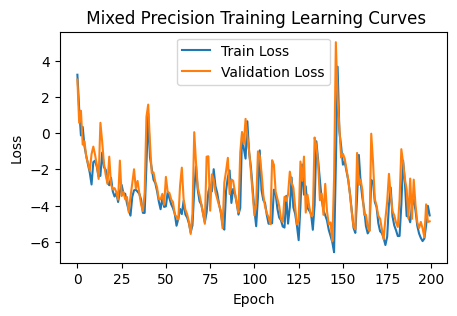

In [96]:
history = mixed_prec_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, " Mixed Precision Training Learning Curves")

Was it heplful? **NO**  
So it won't be present in the next tests

### 3. Warmup

In [109]:
def warmup_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, warmup_epochs=3):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: min(1.0, (epoch + 1) / warmup_epochs)
    )

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= max(len(train_loader), 1)
        scheduler.step()

        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)

        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()

    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [58]:
res = repeated_training(warmup_training)

Training for group Flood:
Avg best val loss: -5.934 | Avg diff damages: 2610217.25 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -6.625 | Avg diff damages: 2515120.25 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -6.261 | Avg diff damages: 466.88 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -7.506 | Avg diff damages: 77371.23 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -6.581 | Overall avg diff damages: 1300793.88 | Overall avg diff casualties: 0.11


In [59]:
print(res)

Overall avg best val loss: -6.581 | Overall avg diff damages: 1300793.88 | Overall avg diff casualties: 0.11


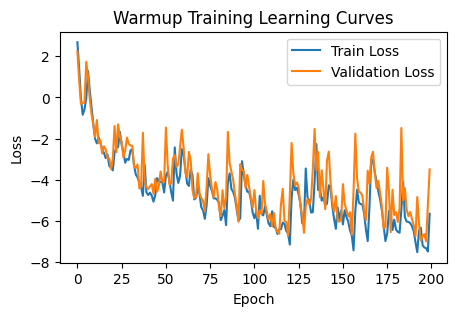

In [110]:
history = warmup_training(dss_c['Wildfire'], epochs=200, warmup_epochs=10)[-1]
plot_learning_curve(history, "Warmup Training Learning Curves")

Was it helpful? **YES**  
It will be included in the next tests

### 4.1. ReduceOnPlateau scheduling

In [111]:
def ROP_scheduling_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, warmup_epochs = 3):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6)
    total_steps = len(train_loader) * epochs
    warmup_steps = len(train_loader) * warmup_epochs
    global_step = 0

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()

            if global_step < warmup_steps:
                for pg in optimizer.param_groups:
                    pg['lr'] = LR * (global_step + 1) / warmup_steps
            global_step += 1

            train_loss += loss.item()

        train_loss /= max(len(train_loader), 1)

        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)

        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()

    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [61]:
res = repeated_training(ROP_scheduling_training)

Training for group Flood:


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Avg best val loss: -5.665 | Avg diff damages: 4261041.00 | Avg diff casualties: 0.03
Training for group Storm:


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Avg best val loss: -8.831 | Avg diff damages: 2647627.75 | Avg diff casualties: 0.08
Training for group Heat:


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Avg best val loss: -5.961 | Avg diff damages: 466.86 | Avg diff casualties: 0.33
Training for group Hail:


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Avg best val loss: -7.731 | Avg diff damages: 78206.02 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -7.047 | Overall avg diff damages: 1746835.50 | Overall avg diff casualties: 0.11


In [62]:
print(res)

Overall avg best val loss: -7.047 | Overall avg diff damages: 1746835.50 | Overall avg diff casualties: 0.11


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


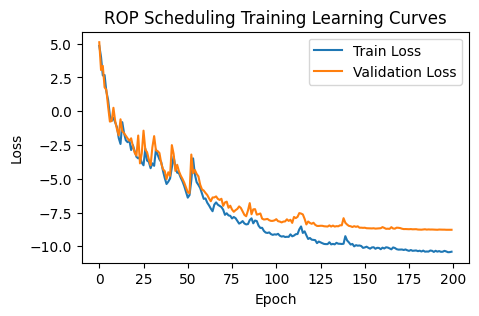

In [112]:
history = ROP_scheduling_training(dss_c['Wildfire'], epochs=200, warmup_epochs=10)[-1]
plot_learning_curve(history, "ROP Scheduling Training Learning Curves")

Was it helpful? **YES**  
But It will not be used for the next tests, as 4.2 is better

### 4.2. Cosine scheduling

In [114]:
def cosine_scheduling_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [67]:
res = repeated_training(cosine_scheduling_training)

Training for group Flood:
Avg best val loss: -8.955 | Avg diff damages: 2516592.25 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -11.521 | Avg diff damages: 2694640.25 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -8.404 | Avg diff damages: 466.86 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -9.680 | Avg diff damages: 78555.57 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -9.640 | Overall avg diff damages: 1322563.75 | Overall avg diff casualties: 0.11


In [68]:
print(res)

Overall avg best val loss: -9.640 | Overall avg diff damages: 1322563.75 | Overall avg diff casualties: 0.11


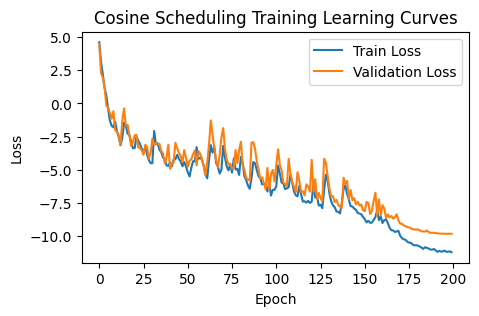

In [102]:
history = cosine_scheduling_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "Cosine Scheduling Training Learning Curves")

Was it helpful? **YES**  
It will be included in the next tests

### 5. Gradient clipping

In [103]:
def grad_clipping_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [70]:
res = repeated_training(grad_clipping_training)

Training for group Flood:
Avg best val loss: -7.923 | Avg diff damages: 11538409.00 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -10.039 | Avg diff damages: 2500933.50 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -7.556 | Avg diff damages: 466.86 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -9.283 | Avg diff damages: 78230.26 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -8.700 | Overall avg diff damages: 3529509.75 | Overall avg diff casualties: 0.11


In [71]:
print(res)

Overall avg best val loss: -8.700 | Overall avg diff damages: 3529509.75 | Overall avg diff casualties: 0.11


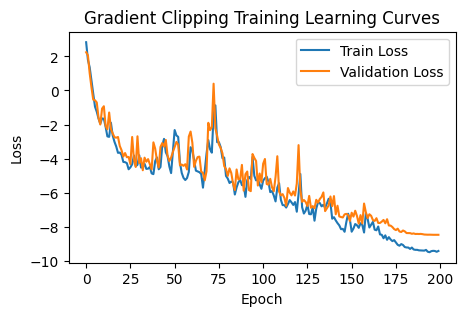

In [104]:
history = grad_clipping_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "Gradient Clipping Training Learning Curves")

Was it helpful? **NO**  
It will not be included in the next tests

### 6. EMA weight update

In [105]:
def ema_update_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    ema_model = torch.optim.swa_utils.AveragedModel(flow)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()
            ema_model.update_parameters(flow)
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        ema_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -ema_model(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = ema_model.state_dict()

    if best_state_dict is not None:
        ema_model.load_state_dict(best_state_dict)

    ema_model.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        ema_model, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [73]:
res = repeated_training(ema_update_training)

Training for group Flood:
Avg best val loss: -4.669 | Avg diff damages: 2902021.00 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -5.173 | Avg diff damages: 2413155.00 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -4.545 | Avg diff damages: 466.87 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -4.301 | Avg diff damages: 77850.40 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -4.672 | Overall avg diff damages: 1348373.38 | Overall avg diff casualties: 0.11


In [74]:
print(res)

Overall avg best val loss: -4.672 | Overall avg diff damages: 1348373.38 | Overall avg diff casualties: 0.11


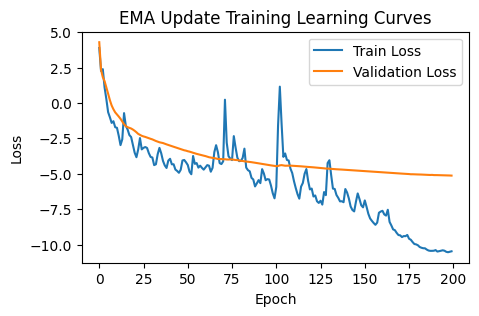

In [113]:
history = ema_update_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "EMA Update Training Learning Curves")

Was it helpful? **NO**  
It will not be included in the next tests

### 7. PAL loss

In [129]:
def PAL_loss_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, threshold=1e-3, lam=3):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            
            # PAL loss
            dist = flow(x)
            log_prob = dist.log_prob(y)
            extreme = (y > threshold).any(dim=1)
            weight = 1 + lam * extreme.float()
            loss = -(weight * log_prob).mean()

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [130]:
res = repeated_training(PAL_loss_training)

Training for group Flood:
Avg best val loss: -8.707 | Avg diff damages: 3054176.75 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -11.458 | Avg diff damages: 2935986.25 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -8.491 | Avg diff damages: 466.86 | Avg diff casualties: 0.37
Training for group Hail:
Avg best val loss: -9.940 | Avg diff damages: 80050.37 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -9.649 | Overall avg diff damages: 1517670.12 | Overall avg diff casualties: 0.12


In [131]:
print(res)

Overall avg best val loss: -9.649 | Overall avg diff damages: 1517670.12 | Overall avg diff casualties: 0.12


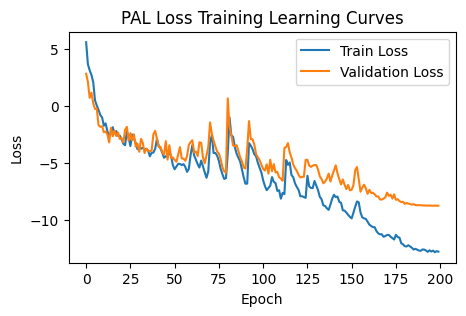

In [121]:
history = PAL_loss_training(dss_c['Wildfire'], epochs=200, threshold=1e-3, lam=2)[-1]
plot_learning_curve(history, "PAL Loss Training Learning Curves")

Was it helpful? **NO**  
And it introduces overfitting => It will not be included in the next tests

## Architectural variations

### 8.1. More layers

In [133]:
def more_layers_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [134]:
res = repeated_training(more_layers_training)

Training for group Flood:
Avg best val loss: -9.197 | Avg diff damages: 2553530.75 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -11.794 | Avg diff damages: 2620968.75 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -9.847 | Avg diff damages: 466.85 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -11.513 | Avg diff damages: 78467.20 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -10.588 | Overall avg diff damages: 1313358.38 | Overall avg diff casualties: 0.11


In [135]:
print(res)

Overall avg best val loss: -10.588 | Overall avg diff damages: 1313358.38 | Overall avg diff casualties: 0.11


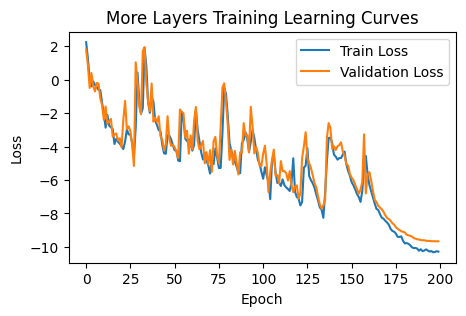

In [136]:
history = more_layers_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "More Layers Training Learning Curves")

### 8.2. More parameters

In [137]:
def more_params_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[512, 512],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [138]:
res = repeated_training(more_params_training)

Training for group Flood:
Avg best val loss: -8.160 | Avg diff damages: 2679937.50 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -10.565 | Avg diff damages: 2648509.00 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -8.133 | Avg diff damages: 466.85 | Avg diff casualties: 0.32
Training for group Hail:
Avg best val loss: -11.019 | Avg diff damages: 78776.22 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -9.469 | Overall avg diff damages: 1351922.38 | Overall avg diff casualties: 0.11


In [139]:
print(res)

Overall avg best val loss: -9.469 | Overall avg diff damages: 1351922.38 | Overall avg diff casualties: 0.11


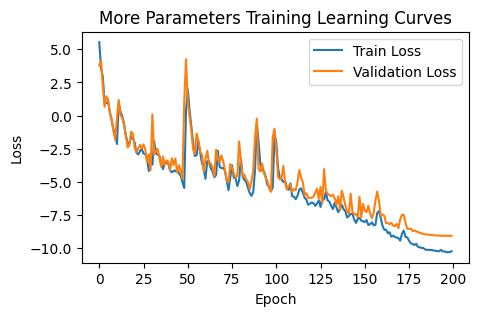

In [140]:
history = more_params_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "More Parameters Training Learning Curves")

### 8.3. More transforms

In [141]:
def more_transf_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=16,
        hidden_features=[256, 256],
        bins=16,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [142]:
res = repeated_training(more_transf_training)

Training for group Flood:
Avg best val loss: -8.847 | Avg diff damages: 2429690.00 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -11.044 | Avg diff damages: 2587796.75 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -8.700 | Avg diff damages: 466.85 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -10.161 | Avg diff damages: 78098.22 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -9.688 | Overall avg diff damages: 1274013.00 | Overall avg diff casualties: 0.11


In [143]:
print(res)

Overall avg best val loss: -9.688 | Overall avg diff damages: 1274013.00 | Overall avg diff casualties: 0.11


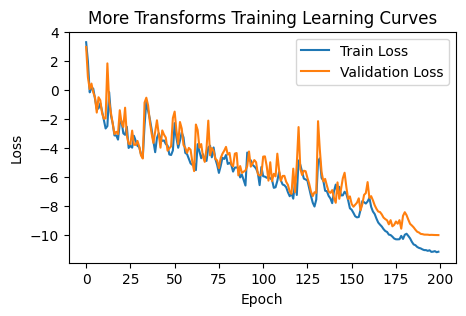

In [144]:
history = more_transf_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "More Transforms Training Learning Curves")

### 8.4. More bins

In [145]:
def more_bins_training(ds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    flow = zuko.flows.NSF(
        features=2,
        context=21,
        transforms=8,
        hidden_features=[256, 256],
        bins=32,
    )

    train_loader = DataLoader(ds['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(ds['val'],   batch_size=batch_size)
    test_loader  = DataLoader(ds['test'],  batch_size=batch_size)

    flow = flow.to(device)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
    total_steps = epochs * len(train_loader)
    warmup_steps = 5 * len(train_loader)

    history = utils.TrainingHistory()
    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(epochs):
        t0 = time.time()
        flow.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = -flow(x).log_prob(y).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            global_step += 1
            if global_step < warmup_steps:
                lr_scale = global_step / warmup_steps
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
            for pg in optimizer.param_groups:
                pg['lr'] = LR * lr_scale

        train_loss /= max(len(train_loader), 1)
        flow.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                loss = -flow(x).log_prob(y).mean()
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)
        history.train_losses.append(train_loss)
        history.val_losses.append(val_loss)
        history.lrs.append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = flow.state_dict()

    if best_state_dict is not None:
        flow.load_state_dict(best_state_dict)

    flow.eval()
    avg_diff_damages, avg_diff_casualties = utils.compute_avg_true_pred_diff(
        flow, test_loader, ds['y_scaler'], device
    )

    return best_val_loss, avg_diff_damages, avg_diff_casualties, history

In [146]:
res = repeated_training(more_bins_training)

Training for group Flood:
Avg best val loss: -9.675 | Avg diff damages: 2379634.50 | Avg diff casualties: 0.03
Training for group Storm:
Avg best val loss: -10.552 | Avg diff damages: 2801675.75 | Avg diff casualties: 0.08
Training for group Heat:
Avg best val loss: -8.712 | Avg diff damages: 466.86 | Avg diff casualties: 0.33
Training for group Hail:
Avg best val loss: -10.062 | Avg diff damages: 78490.52 | Avg diff casualties: 0.00

 Average over all groups:
Overall avg best val loss: -9.751 | Overall avg diff damages: 1315066.88 | Overall avg diff casualties: 0.11


In [147]:
print(res)

Overall avg best val loss: -9.751 | Overall avg diff damages: 1315066.88 | Overall avg diff casualties: 0.11


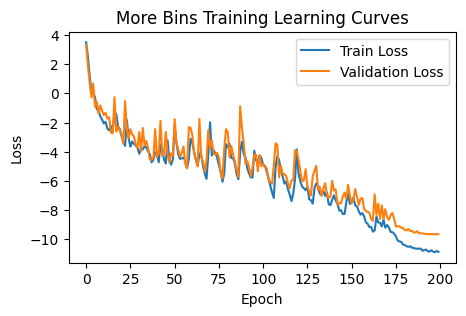

In [148]:
history = more_bins_training(dss_c['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "More Bins Training Learning Curves")

## Data

### 9. Casualties dequantization

In [162]:
def split_normalize_datasets_dequantized(dss, device='cpu'):
    dss1 = {}
    for group, xy in dss.items():
        X,Y = xy
        # Dequantize Y[:,1] by adding uniform noise in [0, 1)
        Y = Y.copy()
        Y[:, 1] = Y[:, 1] + np.random.uniform(0, 1, size=Y.shape[0])

        Y = np.log1p(Y)
        X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
        X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
        
        x_scaler = StandardScaler()
        y_scaler = StandardScaler()
        X_train = x_scaler.fit_transform(X_train)
        X_val   = x_scaler.transform(X_val)
        X_test  = x_scaler.transform(X_test)
        Y_train = y_scaler.fit_transform(Y_train)
        Y_val   = y_scaler.transform(Y_val)
        Y_test  = y_scaler.transform(Y_test)

        X_train = torch.tensor(X_train).to(device)
        Y_train = torch.tensor(Y_train).to(device)
        X_val = torch.tensor(X_val).to(device)
        Y_val = torch.tensor(Y_val).to(device)
        X_test = torch.tensor(X_test).to(device)
        Y_test = torch.tensor(Y_test).to(device)

        train_ds = TensorDataset(X_train, Y_train)
        val_ds   = TensorDataset(X_val, Y_val)
        test_ds   = TensorDataset(X_test, Y_test)

        dss1[group] = {
            'train': train_ds,
            'val': val_ds,
            'test': test_ds,
            'x_scaler': x_scaler,
            'y_scaler': y_scaler
        }
    return dss1

In [163]:
dss = utils.get_datasets_from_dataframes(dfs)
dss_deq = split_normalize_datasets_dequantized(dss, device=device)
dss_c = utils.get_datasets_from_dataframes(dfs_c)
dss_c_deq = split_normalize_datasets_dequantized(dss_c, device=device)

In [164]:
res = repeated_training(cosine_scheduling_training, dss=dss_deq)

Training for group Flood:
Avg best val loss: -2.136 | Avg diff damages: 2968225.25 | Avg diff casualties: 0.53
Training for group Storm:
Avg best val loss: -4.703 | Avg diff damages: 2694364.50 | Avg diff casualties: 0.58
Training for group Heat:
Avg best val loss: -3.390 | Avg diff damages: 466.85 | Avg diff casualties: 0.80
Training for group Hail:
Avg best val loss: -3.752 | Avg diff damages: 78749.99 | Avg diff casualties: 0.50

 Average over all groups:
Overall avg best val loss: -3.495 | Overall avg diff damages: 1435451.75 | Overall avg diff casualties: 0.60


In [165]:
print(res)

Overall avg best val loss: -3.495 | Overall avg diff damages: 1435451.75 | Overall avg diff casualties: 0.60


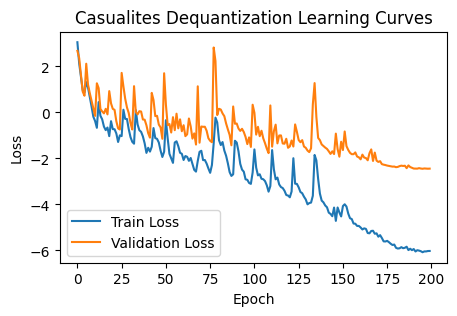

In [166]:
history = cosine_scheduling_training(dss_c_deq['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "Casualites Dequantization Learning Curves")

Was it helpful? **NO**  
And it introduces overfitting => It will not be included in the next tests

### 10. Dataset undersampling

In [175]:
def get_disaster_events_group_undersampled_df(group_name, undersample_frac=0.01):
    if isinstance(group_name, str):
        all_groups = utils.get_all_disaster_events_group_df()
        # undersample the disasters events with both 0 damages and 0 casualties by 1/100
        for group in all_groups:
            group_df = all_groups[group]
            mask = (group_df['DAMAGES'] == 0) & (group_df['CASUALTIES'] == 0)
            undersampled_df = group_df[mask].sample(frac=undersample_frac, random_state=SEEDS[0])
            all_groups[group] = pd.concat([group_df[~mask], undersampled_df])
        return all_groups[group_name]
    elif isinstance(group_name, list):
        all_groups = utils.get_all_disaster_events_group_df()
        # undersample the disasters events with both 0 damages and 0 casualties by 1/100
        for group in all_groups:
            group_df = all_groups[group]
            mask = (group_df['DAMAGES'] == 0) & (group_df['CASUALTIES'] == 0)
            undersampled_df = group_df[mask].sample(frac=undersample_frac, random_state=SEEDS[0])
            all_groups[group] = pd.concat([group_df[~mask], undersampled_df])
        return {group: all_groups[group] for group in group_name}

In [176]:
dfs_und = get_disaster_events_group_undersampled_df(EVENT_GROUPS, undersample_frac=0.1)
dss_und = utils.get_datasets_from_dataframes(dfs_und)
dss_und = utils.split_normalize_datasets(dss_und, device=device)
dfs_c_und = get_disaster_events_group_undersampled_df(['Wildfire'], undersample_frac=0.1)
dss_c_und = utils.get_datasets_from_dataframes(dfs_c)
dss_c_und = utils.split_normalize_datasets(dss_c, device=device)

In [177]:
res = repeated_training(cosine_scheduling_training, dss=dss_und)

Training for group Flood:
Avg best val loss: -4.848 | Avg diff damages: 19295100.00 | Avg diff casualties: 0.06
Training for group Storm:
Avg best val loss: -5.025 | Avg diff damages: 13086387.00 | Avg diff casualties: 0.59
Training for group Heat:
Avg best val loss: -3.489 | Avg diff damages: 4305.97 | Avg diff casualties: 1.57
Training for group Hail:
Avg best val loss: -5.019 | Avg diff damages: 2846676.75 | Avg diff casualties: 0.01

 Average over all groups:
Overall avg best val loss: -4.595 | Overall avg diff damages: 8808118.00 | Overall avg diff casualties: 0.56


In [178]:
print(res)

Overall avg best val loss: -4.595 | Overall avg diff damages: 8808118.00 | Overall avg diff casualties: 0.56


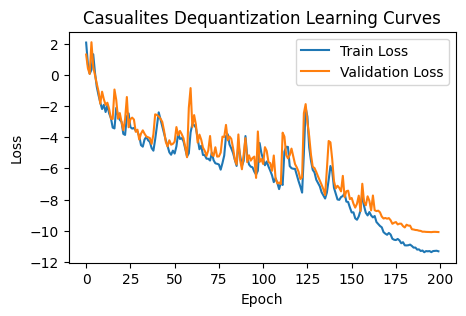

In [179]:
history = cosine_scheduling_training(dss_c_und['Wildfire'], epochs=200)[-1]
plot_learning_curve(history, "Casualites Dequantization Learning Curves")

Was it helpful? **MAYBE**  
It will not be included in the final training, but it might be taken into further consideration